### Структура проекта и наследования

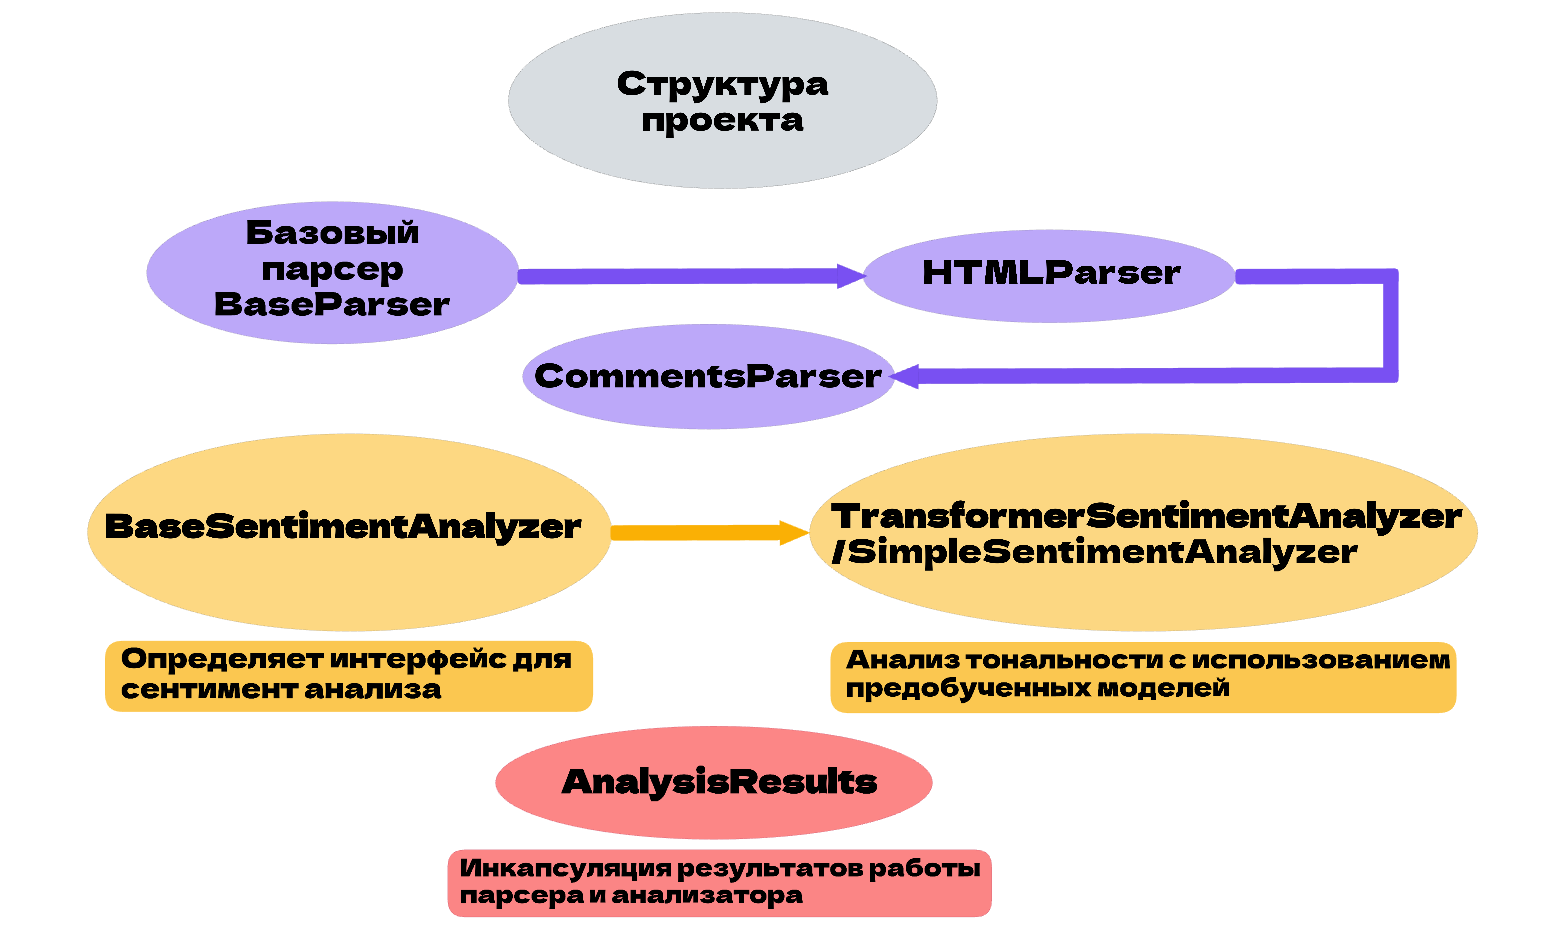

## ***Блок 0: Установка***


In [1]:
!pip install requests beautifulsoup4
!pip install transformers torch
!pip install pandas numpy
!pip install nltk

In [2]:
import nltk

## ***Блок 1: Основные классы и настройки***

In [11]:
from abc import ABC, abstractmethod
import requests
from bs4 import BeautifulSoup
from typing import List, Dict, Optional, Any
import time
import logging
from urllib.parse import urlparse
import re
from dataclasses import dataclass, field
from enum import Enum
import os
from google.colab import userdata
import unittest
from unittest.mock import patch, MagicMock
import nltk
nltk.download('punkt_tab')
# URL статьи для анализа
article_url = "https://lenta.ru/articles/2025/12/24/fontany-reki-i-kanaly-kipyatka/"

# Получение HF_TOKEN из секретов Colab
try:
    hf_token = userdata.get('HF_TOKEN')
    print("HF_TOKEN успешно загружен из секретов Colab")

    os.environ['HF_TOKEN'] = hf_token

    if 'HF_TOKEN' in os.environ and os.environ['HF_TOKEN'].startswith('hf_'):
        print("Переменная окружения HF_TOKEN успешно установлена")
    else:
        print("HF_TOKEN установлен, но имеет некорректный формат (должен начинаться с 'hf_')")

except Exception as e:
    print(f"Ошибка при получении HF_TOKEN: {str(e)}")

# Настройка логирования
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

# Исключения
class ParsingError(Exception):
    """Базовое исключение для ошибок парсинга"""
    pass

class NetworkError(Exception):
    """Исключение для сетевых ошибок"""
    pass

# Декораторы
def log_execution_time(func):
    """Декоратор для логирования времени выполнения метода"""
    def wrapper(*args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        logging.info(f"Метод {func.__name__} выполнен за {end_time - start_time:.2f} секунд")
        return result
    return wrapper

def retry_on_network_error(max_retries: int = 3):
    """Декоратор для повторных попыток при сетевых ошибках"""
    def decorator(func):
        def wrapper(*args, **kwargs):
            last_exception = None
            for attempt in range(max_retries):
                try:
                    return func(*args, **kwargs)
                except NetworkError as e:
                    last_exception = e
                    logging.warning(f"Попытка {attempt + 1} не удалась: {e}")
                    if attempt < max_retries - 1:
                        time.sleep(2 ** attempt)
            raise last_exception
        return wrapper
    return decorator



[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


HF_TOKEN успешно загружен из секретов Colab
Переменная окружения HF_TOKEN успешно установлена


### **Блок 2: Базовый парсер**


In [4]:
class BaseParser(ABC):
    """
    Абстрактный класс базового парсера, определяющий общий интерфейс для всех парсеров.
    """
    def __init__(self, timeout: int = 10, headers: Dict[str, str] = None):
        """
        Инициализация парсера

        Args:
            timeout: время ожидания запроса в секундах
            headers: заголовки HTTP-запроса
        """
        self.timeout = timeout
        self.headers = headers or {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
            'Accept-Language': 'ru-RU,ru;q=0.9,en-US;q=0.8,en;q=0.7',
            'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8',
            'Connection': 'keep-alive',
            'Upgrade-Insecure-Requests': '1'
        }

    @abstractmethod
    def parse(self, source: str) -> List[str]:
        """
        Абстрактный метод для парсинга данных из источника
        Args:
            source: URL или путь к файлу для парсинга
        Returns:
            Список извлеченных текстов
        """
        pass

    @abstractmethod
    def validate_content(self, content: str) -> bool:
        """
        Абстрактный метод для валидации содержимого
        Args:
            content: содержимое для валидации
        Returns:
            True если содержимое валидно, иначе False
        """
        pass

    def preprocess_content(self, content: str) -> str:
        """
        Метод для предварительной обработки содержимого
        Args:
            content: исходное содержимое
        Returns:
            обработанное содержимое
        """
        return ' '.join(content.split())

    def _is_valid_url(self, url: str) -> bool:
        """
        Проверка валидности URL
        Args:
            url: URL для проверки
        Returns:
            True если URL валиден, иначе False
        """
        try:
            result = urlparse(url.strip())
            return all([result.scheme, result.netloc])
        except Exception:
            return False

# Юнит-тесты для базового парсера
if __name__ == "__main__":
    class ConcreteParser(BaseParser):
        def parse(self, source: str) -> List[str]:
            return ["parsed text"]
        def validate_content(self, content: str) -> bool:
            return True

    class TestBaseParser(unittest.TestCase):
        """Тесты для базового парсера"""

        def setUp(self):
            self.parser = ConcreteParser()

        def test_preprocess_content(self):
            """Проверка предварительной обработки контента"""
            test_cases = [
                ("  Hello   world  ", "Hello world"),
                ("Line1\nLine2\n\nLine3", "Line1 Line2 Line3"),
                ("Multiple     spaces", "Multiple spaces"),
                ("", "")
            ]

            for input_text, expected in test_cases:
                self.assertEqual(self.parser.preprocess_content(input_text), expected)

        def test_is_valid_url(self):
            """Проверка валидации URL"""
            valid_urls = [
                article_url.strip(),
                "https://example.com",
                "http://test.ru/page"
            ]
            invalid_urls = [
                "example.com",
                "http:/example.com",
                "https://",
                "",
                None
            ]

            for url in valid_urls:
                self.assertTrue(self.parser._is_valid_url(url), f"URL должен быть валидным: {url}")

            for url in invalid_urls:
                self.assertFalse(self.parser._is_valid_url(url), f"URL должен быть невалидным: {url}")



In [5]:
test_suite = unittest.TestLoader().loadTestsFromTestCase(TestBaseParser)
runner = unittest.TextTestRunner(verbosity=2)
result = runner.run(test_suite)

if result.wasSuccessful():
  print("\n✓ Все тесты пройдены успешно!")
else:
  print(f"\n✗ Некоторые тесты не пройдены: {len(result.failures)} ошибок")

test_is_valid_url (__main__.TestBaseParser.test_is_valid_url)
Проверка валидации URL ... ok
test_preprocess_content (__main__.TestBaseParser.test_preprocess_content)
Проверка предварительной обработки контента ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.016s

OK



✓ Все тесты пройдены успешно!


### ***Блок 3: Парсер HTML***

In [6]:
class HTMLParser(BaseParser):
    def __init__(self,
                 timeout: int = 10,
                 headers: Dict[str, str] = None,
                 default_text_selectors: List[str] = None):
        """
        Инициализация HTML-парсера
        Args:
            timeout: время ожидания запроса в секундах
            headers: заголовки HTTP-запроса
            default_text_selectors: список CSS-селекторов для извлечения текста по умолчанию
        """
        super().__init__(timeout, headers)
        self.default_text_selectors = default_text_selectors or [
            '.article__text', '.article__block', '.article__body', '.article__content',
            '.g-article-text', '.article-content', '.post-content',
            'p', 'div.text', 'div.content', 'article', 'section',
            'h1', 'h2', 'h3', 'h4', 'h5', 'h6'
        ]
        self.session = requests.Session()
        self.session.headers.update(self.headers)
        self.session.cookies.set('cookie_policy', '1')

    @retry_on_network_error(max_retries=3)
    @log_execution_time
    def fetch_content(self, url: str) -> str:
        """
        Метод для загрузки HTML-контента по URL
        Args:
            url: URL веб-страницы
        Returns:
            HTML-контент страницы
        Raises:
            NetworkError: при сетевых ошибках
            ParsingError: при ошибках получения контента
        """
        try:
            url = url.strip()
            response = self.session.get(url, timeout=self.timeout)

            if response.status_code == 404:
                raise ParsingError(f"Страница не найдена (404): {url}")
            elif response.status_code >= 400:
                raise NetworkError(f"Ошибка сервера ({response.status_code}): {url}")

            response.raise_for_status()

            # Автоопределение кодировки
            if response.encoding == 'ISO-8859-1' or not response.encoding:
                response.encoding = response.apparent_encoding or 'utf-8'

            content = response.text

            if any(keyword in content.lower() for keyword in ['captcha', 'cloudflare', 'блокировка', 'доступ ограничен']):
                logging.warning("Обнаружены признаки блокировки или капчи")
                raise NetworkError(f"Доступ к {url} ограничен (возможно, требуется верификация)")

            return content

        except requests.exceptions.RequestException as e:
            raise NetworkError(f"Ошибка при загрузке страницы {url}: {str(e)}")
        except Exception as e:
            raise ParsingError(f"Неожиданная ошибка при загрузке {url}: {str(e)}")

    def parse(self, source: str) -> List[str]:
        """
        Основной метод для парсинга HTML-контента
        Args:
            source: URL веб-страницы для парсинга
        Returns:
            Список извлеченных текстов
        """
        if not self._is_valid_url(source):
            raise ParsingError(f"Невалидный URL: {source}")

        html_content = self.fetch_content(source)

        if not self.validate_content(html_content):
            logging.warning("Контент не прошел валидацию, но продолжаем парсинг")

        soup = BeautifulSoup(html_content, 'html.parser')

        # Удаляем скрипты и стили для чистоты извлечения текста
        for script in soup(["script", "style", "noscript", "iframe", "header", "footer", "nav", "aside", "form"]):
            script.decompose()

        extracted_texts = []
        domain = urlparse(source).netloc.lower()

        # Универсальные селекторы
        selectors = self.default_text_selectors.copy()
        universal_selectors = [
            '.article-content', '.post-content', '.content-body',
            '.news-content', '.story-content', '.main-content',
            '.entry-content', '.post-body', '.article-body',
            '[itemprop="articleBody"]', '[property="articleBody"]'
        ]

        # Добавляем универсальные селекторы к основным
        selectors.extend(universal_selectors)

        # Убираем дубликаты
        selectors = list(dict.fromkeys(selectors))

        for selector in selectors:
            elements = soup.select(selector)
            for element in elements:
                text = element.get_text(strip=True)
                if text and len(text) > 25 and not self._is_navigation_text(text):
                    if self._is_news_content(text, domain):
                        processed_text = self.preprocess_content(text)
                        if processed_text and len(processed_text) > 25:
                            extracted_texts.append(processed_text)

        # Если не нашли достаточно текста, пробуем альтернативные методы
        if len(extracted_texts) < 3:
            article = soup.find('article')
            if article:
                paragraphs = article.find_all('p')
                for p in paragraphs:
                    text = p.get_text(strip=True)
                    if text and len(text) > 25 and not self._is_navigation_text(text):
                        extracted_texts.append(self.preprocess_content(text))

        # Убираем дубликаты, сохраняя порядок
        unique_texts = []
        seen = set()
        for text in extracted_texts:
            if text not in seen:
                seen.add(text)
                unique_texts.append(text)

        return unique_texts[:30]  # Ограничиваем количество текстов

    def validate_content(self, content: str) -> bool:
        """
        Валидация HTML-контента
        Args:
            content: HTML-контент для валидации
        Returns:
            True если контент валиден, иначе False
        """
        if not content or not isinstance(content, str):
            return False

        stripped_content = content.strip()
        if len(stripped_content) < 800:
            return True  # Не считаем короткий контент ошибкой

        content_lower = stripped_content.lower()

        # Проверка на реальные ошибки сервера
        critical_error_indicators = [
            '<title>404</title>', '<title>403</title>', '<title>500</title>',
            '<h1>404</h1>', '<h1>403</h1>', '<h1>500</h1>',
            'error 404', 'error 403', 'error 500',
            'страница не найдена', 'доступ запрещен', 'внутренняя ошибка сервера'
        ]

        beginning_content = content_lower[:1000]
        if any(indicator in beginning_content for indicator in critical_error_indicators):
            return False

        return True

    def _is_news_content(self, text: str, domain: str) -> bool:
        """
        Проверка, является ли текст частью новостного контента
        """
        text_lower = text.lower()

        nav_keywords = [
            'подписаться', 'реклама', 'копировать', 'поделиться',
            'комментарии', 'просмотров', 'источник',
            'читайте также', 'также по теме', 'похожие новости',
            'главное сегодня', 'популярное', 'политика конфиденциальности'
        ]

        if any(keyword in text_lower for keyword in nav_keywords) and len(text) < 60:
            return False

        if 'lenta.ru' in domain and 'блок' in text_lower:
            if any(keyword in text_lower for keyword in ['россия', 'санкции', 'америка']):
                return True

        return True

    def _is_navigation_text(self, text: str) -> bool:
        """
        Проверка, является ли текст частью навигации
        """
        navigation_keywords = [
            'главная', 'новости', 'рубрики', 'категории',
            'архив', 'поиск', 'войти', 'регистрация',
            'подписка', 'реклама', 'контакты', 'о нас', 'политика',
            'наверх', 'вниз', 'печать', 'поделиться', 'лайк', 'комментарий'
        ]
        text_lower = text.lower()
        return any(keyword in text_lower for keyword in navigation_keywords) and len(text) < 100

# Юнит-тесты для HTML парсера
if __name__ == "__main__":
    class TestHTMLParser(unittest.TestCase):
        """Тесты для HTML парсера"""

        def setUp(self):
            """Настройка перед каждым тестом"""
            self.parser = HTMLParser(timeout=5)
            self.mock_html = """
            <html>
            <head><title>Test Page</title></head>
            <body>
                <header>Navigation</header>
                <main>
                    <article>
                        <h1>Main Article</h1>
                        <p>This is the first paragraph of the article.</p>
                        <p>This is the second paragraph with some <strong>important</strong> text.</p>
                        <div class="article-content">
                            <p>Content in special container</p>
                        </div>
                    </article>
                </main>
                <footer>Copyright 2024</footer>
                <script>console.log('test');</script>
                <style>.test { color: red; }</style>
            </body>
            </html>
            """

        @patch('requests.Session.get')
        def test_fetch_content_success(self, mock_get):
            """Проверка успешной загрузки контента"""
            mock_response = MagicMock()
            mock_response.status_code = 200
            mock_response.text = self.mock_html
            mock_response.encoding = 'utf-8'
            mock_response.apparent_encoding = 'utf-8'
            mock_get.return_value = mock_response

            content = self.parser.fetch_content(article_url)
            self.assertEqual(content, self.mock_html)
            mock_get.assert_called_once_with(article_url.strip(), timeout=5)

        def test_is_navigation_text(self):
            """Проверка определения навигационного текста"""
            navigation_texts = [
                "Главная страница",
                "Войти в систему",
                "Контакты",
                "Политика конфиденциальности",
                "Поделиться статьей"
            ]
            content_texts = [
                "Это основной контент статьи с подробным анализом темы.",
                "Результаты исследования показывают значительное улучшение показателей.",
                "The quick brown fox jumps over the lazy dog"
            ]

            for text in navigation_texts:
                self.assertTrue(self.parser._is_navigation_text(text))

            for text in content_texts:
                self.assertFalse(self.parser._is_navigation_text(text))

        def test_preprocess_content(self):
            """Проверка предварительной обработки контента"""
            test_cases = [
                ("  Много    пробелов   и \n\n переносов  ", "Много пробелов и переносов"),
                ("Text\twith\ttabs", "Text with tabs")
            ]

            for input_text, expected in test_cases:
                self.assertEqual(self.parser.preprocess_content(input_text), expected)

    test_suite = unittest.TestLoader().loadTestsFromTestCase(TestHTMLParser)
    runner = unittest.TextTestRunner(verbosity=2)
    result = runner.run(test_suite)

    if result.wasSuccessful():
      print("\n✓ Все тесты пройдены успешно!")
    else:
      print(f"\n✗ Некоторые тесты не пройдены: {len(result.failures)} ошибок")

test_fetch_content_success (__main__.TestHTMLParser.test_fetch_content_success)
Проверка успешной загрузки контента ... ok
test_is_navigation_text (__main__.TestHTMLParser.test_is_navigation_text)
Проверка определения навигационного текста ... ok
test_preprocess_content (__main__.TestHTMLParser.test_preprocess_content)
Проверка предварительной обработки контента ... ok

----------------------------------------------------------------------
Ran 3 tests in 0.055s

OK



✓ Все тесты пройдены успешно!


### ***Блок 4: Специализированный парсер отзывов***

In [7]:
class CommentsParser(HTMLParser):
    def __init__(self,
                 timeout: int = 10,
                 headers: Dict[str, str] = None,
                 comment_selectors: List[str] = None,
                 author_selectors: List[str] = None,
                 date_selectors: List[str] = None):
        """
        Инициализация парсера комментариев
        Args:
            timeout: время ожидания запроса в секундах
            headers: заголовки HTTP-запроса
            comment_selectors: селекторы для контейнеров с комментариями
            author_selectors: селекторы для авторов комментариев
            date_selectors: селекторы для даты комментариев
        """
        default_text_selectors = [
            '.comment-text', '.comment__text', '.comment-content',
            '.comment-body', '.review-text', '.feedback-text',
            '.text', '.content', 'p'
        ]

        super().__init__(timeout, headers, default_text_selectors)

        self.comment_selectors = comment_selectors or [
            '.comment', '.comments__item', '.comment-item', '.reply',
            '.comment-block', '.comment-section', '.discussion-item'
        ]

        self.author_selectors = author_selectors or [
            '.comment-author', '.author', '.username', '.comment-by',
            '.user-name', '.comment-writer'
        ]

        self.date_selectors = date_selectors or [
            '.comment-date', '.date', '.timestamp', '.published',
            '.time', '.comment-time'
        ]

    def parse(self, source: str) -> List[str]:
        """
        Основной метод для парсинга комментариев
        Args:
            source: URL страницы с комментариями
        Returns:
            Список текстов комментариев
        """
        if not self._is_valid_url(source):
            raise ParsingError(f"Невалидный URL для парсинга комментариев: {source}")

        try:
            html_content = self.fetch_content(source)
        except NetworkError as e:
            logging.warning(f"Сетевая ошибка при загрузке комментариев: {e}")
            html_content = ""

        soup = BeautifulSoup(html_content, 'html.parser')
        comment_containers = self._find_comment_containers(soup)

        if not comment_containers:
            return self._extract_fallback_comments(soup)

        comment_texts = []
        for container in comment_containers:
            comment_text = self._extract_comment_text(container)
            if comment_text and len(comment_text) > 20:
                comment_texts.append(comment_text)

        if not comment_texts:
            return self._extract_fallback_comments(soup)

        return comment_texts

    def _find_comment_containers(self, soup: BeautifulSoup) -> List[Any]:
        """
        Поиск контейнеров с комментариями на странице
        """
        containers = []

        for selector in self.comment_selectors:
            found = soup.select(selector)
            if found:
                containers.extend(found)

        if not containers:
            data_containers = soup.find_all(attrs={
                "data-comment": True,
                "data-reply": True,
                "data-discussion": True
            }, recursive=True)

            if data_containers:
                containers.extend(data_containers)

            if not containers:
                class_keywords = ['comment', 'reply', 'discussion']
                for tag in soup.find_all(['div', 'article', 'section', 'li']):
                    class_list = tag.get('class', [])
                    if isinstance(class_list, list):
                        for class_name in class_list:
                            if any(keyword in class_name.lower() for keyword in class_keywords):
                                containers.append(tag)
                                break

        # Удаляем дубликаты
        unique_containers = []
        seen = set()
        for container in containers:
            container_id = id(container)
            if container_id not in seen:
                seen.add(container_id)
                unique_containers.append(container)

        return unique_containers

    def _extract_comment_text(self, container: Any) -> Optional[str]:
        """
        Извлечение текста комментария из контейнера
        """
        for selector in self.default_text_selectors:
            elements = container.select(selector)
            if elements:
                for element in elements:
                    text = element.get_text(strip=True)
                    if text and len(text) > 20:
                        return self.preprocess_content(text)

        # Резервный метод
        for child in container.find_all(['script', 'style', 'button', 'a', 'img', 'form']):
            child.decompose()

        for selector in self.author_selectors + self.date_selectors:
            for element in container.select(selector):
                element.decompose()

        text = container.get_text(strip=True)
        if text and len(text) > 20:
            return self.preprocess_content(text)

        return None

    def _extract_fallback_comments(self, soup: BeautifulSoup) -> List[str]:
        """
        Резервный метод извлечения комментариев
        """
        for element in soup(['header', 'footer', 'nav', 'aside', 'script', 'style', 'form']):
            element.decompose()

        paragraphs = soup.find_all('p')
        potential_comments = []

        for p in paragraphs:
            text = p.get_text(strip=True)
            if text and 30 < len(text) < 500:
                text_lower = text.lower()
                comment_indicators = ['комментарий', 'автор', 'написал', 'думает',
                                    'считает', 'говорит', 'отмечает', 'пишет']
                if any(indicator in text_lower for indicator in comment_indicators):
                    potential_comments.append(self.preprocess_content(text))

        return potential_comments[:20]

    def get_detailed_comments(self, source: str) -> List[Dict[str, Any]]:
        """
        Получение детальной информации о комментариях
        Args:
            source: URL страницы с комментариями
        Returns:
            Список словарей с детальной информацией о комментариях
        """
        html_content = self.fetch_content(source)
        soup = BeautifulSoup(html_content, 'html.parser')

        comment_containers = self._find_comment_containers(soup)
        detailed_comments = []

        for container in comment_containers:
            comment_text = self._extract_comment_text(container)
            if not comment_text or len(comment_text) < 20:
                continue

            comment_data = {
                'text': comment_text,
                'author': self._extract_author(container),
                'date': self._extract_date(container),
                'url': source
            }
            detailed_comments.append(comment_data)

        return detailed_comments

    def _extract_author(self, container: Any) -> Optional[str]:
        """Извлечение автора комментария"""
        for selector in self.author_selectors:
            element = container.select_one(selector)
            if element:
                text = element.get_text(strip=True)
                if text and len(text) > 1:
                    return self.preprocess_content(text)
        return None

    def _extract_date(self, container: Any) -> Optional[str]:
        """Извлечение даты комментария"""
        for selector in self.date_selectors:
            element = container.select_one(selector)
            if element:
                text = element.get_text(strip=True)
                if text:
                    return self.preprocess_content(text)
        return None

# Юнит-тесты для парсера комментариев
if __name__ == "__main__":
    class TestCommentsParser(unittest.TestCase):
        """Тесты для парсера комментариев"""

        def setUp(self):
            self.parser = CommentsParser(timeout=5)
            self.mock_comment_html = """
            <html>
            <body>
                <div class="comment">
                    <div class="comment-author">Иван Петров</div>
                    <div class="comment-date">10.12.2024</div>
                    <div class="comment-text">Отличная статья, спасибо за публикацию!</div>
                </div>
                <div class="comment-item">
                    <span class="author">Мария Сидорова</span>
                    <span class="date">11.12.2024</span>
                    <p class="comment-content">Не согласен с автором, ситуация выглядит иначе.</p>
                </div>
                <div class="reply">
                    <h3 class="username">Алексей</h3>
                    <div class="time">вчера</div>
                    <div class="text">Интересный анализ, добавлю свои два цента.</div>
                </div>
            </body>
            </html>
            """

        def test_find_comment_containers(self):
            """Проверка поиска контейнеров с комментариями"""
            soup = BeautifulSoup(self.mock_comment_html, 'html.parser')
            containers = self.parser._find_comment_containers(soup)
            self.assertEqual(len(containers), 3)

        def test_extract_comment_text(self):
            """Проверка извлечения текста комментария"""
            soup = BeautifulSoup(self.mock_comment_html, 'html.parser')
            containers = self.parser._find_comment_containers(soup)
            for container in containers:
                text = self.parser._extract_comment_text(container)
                self.assertIsNotNone(text)
                self.assertGreater(len(text), 20)

    test_suite = unittest.TestLoader().loadTestsFromTestCase(TestCommentsParser)
    runner = unittest.TextTestRunner(verbosity=2)
    result = runner.run(test_suite)

    if result.wasSuccessful():
      print("\n✓ Все тесты пройдены успешно!")
    else:
      print(f"\n✗ Некоторые тесты не пройдены: {len(result.failures)} ошибок")

test_extract_comment_text (__main__.TestCommentsParser.test_extract_comment_text)
Проверка извлечения текста комментария ... ok
test_find_comment_containers (__main__.TestCommentsParser.test_find_comment_containers)
Проверка поиска контейнеров с комментариями ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.035s

OK



✓ Все тесты пройдены успешно!


### ***Блок 5: Анализатор тональности (абстрактный класс)***

In [8]:
class BaseSentimentAnalyzer(ABC):

    def __init__(self):
        self.supported_languages = ['ru', 'en']
        self.min_text_length = 5

    @abstractmethod
    def analyze(self, text: str) -> Dict[str, Any]:
        """
        Абстрактный метод для анализа тональности текста
        Args:
            text: текст для анализа
        Returns:
            словарь с результатами анализа
        """
        pass

    @abstractmethod
    def analyze_batch(self, texts: List[str]) -> List[Dict[str, Any]]:
        """
        Абстрактный метод для анализа тональности списка текстов
        Args:
            texts: список текстов для анализа
        Returns:
            список словарей с результатами анализа
        """
        pass

    def preprocess_text(self, text: str) -> str:
        """
        Предварительная обработка текста перед анализом
        Args:
            text: исходный текст
        Returns:
            обработанный текст
        """
        if not text or not isinstance(text, str):
            raise ValueError("Текст для анализа не может быть пустым или нестроковым значением")

        # Удаление лишних пробелов и переносов строк
        text = ' '.join(text.split())

        # Удаление email адресов и URL
        text = re.sub(r'\S+@\S+', '', text)
        text = re.sub(r'http\S+|www\S+', '', text)

        # Удаление специальных символов, кроме пунктуации
        text = re.sub(r'[^\w\s\.\,\!\?\:\;\-\(\)\"\'\«\»]', ' ', text)

        # Удаление множественных пробелов
        text = re.sub(r'\s+', ' ', text)

        return text.strip()

    def detect_language(self, text: str) -> str:
        """
        Args:
            text: текст для анализа
        Returns:
            код языка ('ru' или 'en')
        """
        text_lower = text.lower()

        # Подсчет частоты русских букв
        ru_chars = sum(1 for c in text_lower if 'а' <= c <= 'я' or c in 'ё')
        # Подсчет частоты английских букв
        en_chars = sum(1 for c in text_lower if 'a' <= c <= 'z')

        total_chars = max(ru_chars + en_chars, 1)

        if ru_chars / total_chars > 0.3:
            return 'ru'
        elif en_chars / total_chars > 0.3:
            return 'en'
        else:
            return 'ru'

    def validate_text(self, text: str) -> bool:
        """
        Валидация текста перед анализом
        Args:
            text: текст для валидации
        Returns:
            True если текст валиден, иначе False
        """
        if not text or not isinstance(text, str):
            return False

        cleaned_text = self.preprocess_text(text)
        return len(cleaned_text) >= self.min_text_length

### ***Блок 6: Реализация анализатора на трансформерах и класс результатов анализа***

In [9]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np
from datetime import datetime
import json
import csv
import pandas as pd
import seaborn as sns
from collections import Counter
import os
from dataclasses import field
from typing import Dict, List, Any, Optional

class TransformerSentimentAnalyzer(BaseSentimentAnalyzer):
    """
    Конкретная реализация анализатора тональности на основе трансформеров.
    Использует предобученную модель для анализа русскоязычных текстов.
    """
    def __init__(self,
                 model_name: str = "blanchefort/rubert-base-cased-sentiment",
                 device: str = None,
                 max_length: int = 512,
                 batch_size: int = 16):
        """
        Инициализация анализатора
        Args:
            model_name: название предобученной модели
            device: устройство для вычислений
            max_length: максимальная длина текста для модели
            batch_size: размер батча для анализа
        """
        super().__init__()
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.max_length = max_length
        self.batch_size = batch_size
        try:
            self.tokenizer = AutoTokenizer.from_pretrained(model_name)
            self.model = AutoModelForSequenceClassification.from_pretrained(model_name)
            self.model.to(self.device)
            self.model.eval()
            # Для русских моделей используем соответствующие метки
            self.class_labels = ['neutral', 'positive', 'negative']
        except Exception as e:
            raise Exception(f"Ошибка при загрузке модели '{model_name}': {str(e)}")

    @torch.no_grad()
    def analyze(self, text: str) -> Dict[str, Any]:
        """
        Анализ тональности одного текста
        Args:
            text: текст для анализа
        Returns:
            словарь с результатами анализа
        """
        if not self.validate_text(text):
            return {
                'text': text[:50] + '...' if len(text) > 50 else text,
                'sentiment': 'neutral',
                'confidence': 0.0,
                'probabilities': {label: 0.0 for label in self.class_labels},
                'language': 'ru',
                'error': 'Текст не прошел валидацию'
            }

        try:
            processed_text = self.preprocess_text(text)
            language = self.detect_language(processed_text)

            inputs = self.tokenizer(
                processed_text,
                padding=True,
                truncation=True,
                max_length=self.max_length,
                return_tensors="pt"
            ).to(self.device)

            outputs = self.model(**inputs)
            probabilities = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]

            max_idx = np.argmax(probabilities)
            sentiment_label = self.class_labels[max_idx]
            confidence = float(probabilities[max_idx])

            sentiment_map = {
                'positive': 'positive',
                'negative': 'negative',
                'neutral': 'neutral'
            }

            sentiment = sentiment_map.get(sentiment_label, 'neutral')

            return {
                'text': processed_text[:100] + '...' if len(processed_text) > 100 else processed_text,
                'sentiment': sentiment,
                'confidence': confidence,
                'probabilities': {
                    label: float(prob)
                    for label, prob in zip(self.class_labels, probabilities)
                },
                'language': language
            }

        except Exception as e:
            return {
                'text': text[:50] + '...' if len(text) > 50 else text,
                'sentiment': 'neutral',
                'confidence': 0.0,
                'probabilities': {label: 0.0 for label in self.class_labels},
                'language': 'ru',
                'error': str(e)
            }

    @torch.no_grad()
    def analyze_batch(self, texts: List[str]) -> List[Dict[str, Any]]:
        """
        Анализ тональности списка текстов
        Args:
            texts: список текстов для анализа
        Returns:
            список словарей с результатами анализа
        """
        results = []

        valid_texts = []
        for text in texts:
            if self.validate_text(text):
                valid_texts.append(self.preprocess_text(text))
            else:
                results.append({
                    'text': text[:50] + '...' if len(text) > 50 else text,
                    'sentiment': 'neutral',
                    'confidence': 0.0,
                    'probabilities': {label: 0.0 for label in self.class_labels},
                    'language': 'ru',
                    'error': 'Текст не прошел валидацию'
                })

        if not valid_texts:
            return results

        try:
            languages = [self.detect_language(text) for text in valid_texts]

            inputs = self.tokenizer(
                valid_texts,
                padding=True,
                truncation=True,
                max_length=self.max_length,
                return_tensors="pt"
            ).to(self.device)

            outputs = self.model(**inputs)
            probabilities = torch.softmax(outputs.logits, dim=1).cpu().numpy()

            for i, (text, probs, lang) in enumerate(zip(valid_texts, probabilities, languages)):
                max_idx = np.argmax(probs)
                sentiment_label = self.class_labels[max_idx]
                confidence = float(probs[max_idx])

                sentiment = {
                    'positive': 'positive',
                    'negative': 'negative',
                    'neutral': 'neutral'
                }.get(sentiment_label, 'neutral')

                results.append({
                    'text': text[:100] + '...' if len(text) > 100 else text,
                    'sentiment': sentiment,
                    'confidence': confidence,
                    'probabilities': {
                        label: float(prob)
                        for label, prob in zip(self.class_labels, probs)
                    },
                    'language': lang,
                    'source_index': i
                })

            return results

        except Exception as e:
            return [{
                'text': text[:50] + '...' if len(text) > 50 else text,
                'sentiment': 'neutral',
                'confidence': 0.0,
                'probabilities': {label: 0.0 for label in self.class_labels},
                'language': 'ru',
                'error': str(e)
            } for text in texts]

    def get_model_info(self) -> Dict[str, Any]:
        """
        Получение информации о модели
        Returns:
            словарь с информацией о модели
        """
        return {
            'model_name': self.model.__class__.__name__,
            'device': str(self.device),
            'class_labels': self.class_labels,
            'max_length': self.max_length
        }

@dataclass
class AnalysisResults:
    """
    Класс для инкапсуляции результатов анализа.
    """
    source_url: str
    texts: List[str]
    sentiments: List[Dict[str, Any]]
    timestamp: str = field(default_factory=lambda: datetime.now().isoformat())
    parser_type: str = "HTMLParser"
    analyzer_type: str = "TransformerSentimentAnalyzer"
    metadata: Dict[str, Any] = field(default_factory=dict)
    stats: Dict[str, Any] = field(default_factory=dict)

    def __post_init__(self):
        """Автоматическое вычисление статистики после инициализации"""
        self._calculate_stats()

    def _calculate_stats(self):
        """Вычисление статистики по результатам анализа"""
        if not self.sentiments:
            self.stats = {
                'total_texts': 0,
                'sentiment_distribution': {},
                'avg_confidence': 0.0,
                'dominant_sentiment': 'neutral'
            }
            return

        sentiment_counts = Counter()
        confidence_sum = 0.0

        for sentiment_result in self.sentiments:
            if isinstance(sentiment_result, dict) and 'sentiment' in sentiment_result:
                sentiment = sentiment_result['sentiment']
                confidence = sentiment_result.get('confidence', 0.0)

                sentiment_counts[sentiment] += 1
                confidence_sum += confidence

        total_texts = len(self.sentiments)

        sentiment_distribution = {
            sentiment: {
                'count': count,
                'percentage': count / total_texts * 100
            }
            for sentiment, count in sentiment_counts.items()
        }

        dominant_sentiment = max(sentiment_counts.items(), key=lambda x: x[1])[0] if sentiment_counts else 'neutral'

        self.stats = {
            'total_texts': total_texts,
            'sentiment_distribution': sentiment_distribution,
            'avg_confidence': confidence_sum / total_texts if total_texts > 0 else 0.0,
            'dominant_sentiment': dominant_sentiment,
            'processing_time': self.metadata.get('processing_time', 0.0)
        }

    def __len__(self) -> int:
        """
        Перегрузка оператора len() для подсчета количества проанализированных текстов
        Returns:
            количество проанализированных текстов
        """
        return len(self.texts)

    def get_summary(self) -> str:
        """Получение текстового сводного отчета"""
        summary = f"Анализ источника: {self.source_url}\n"
        summary += f"Время анализа: {self.timestamp}\n"
        summary += f"Всего проанализировано текстов: {self.stats['total_texts']}\n\n"

        summary += "Распределение тональностей:\n"
        for sentiment, data in self.stats['sentiment_distribution'].items():
            percentage = data['percentage']
            summary += f"{sentiment.capitalize()}: {data['count']} ({percentage:.1f}%)\n"

        summary += f"\nСредняя уверенность модели: {self.stats['avg_confidence']:.3f}\n"
        summary += f"Доминирующая тональность: {self.stats['dominant_sentiment'].capitalize()}\n"

        return summary

    def save_results(self, output_dir: str = "analysis_results", prefix: str = "analysis"):
        """
        Сохранение результатов анализа в файлы
        Args:
            output_dir: директория для сохранения файлов
            prefix: префикс для имен файлов
        Returns:
            словарь с путями к сохраненным файлам
        """
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        os.makedirs(output_dir, exist_ok=True)

        # Сохранение в JSON
        json_path = os.path.join(output_dir, f"{prefix}_{timestamp}.json")
        result_data = {
            'source_url': self.source_url,
            'timestamp': self.timestamp,
            'parser_type': self.parser_type,
            'analyzer_type': self.analyzer_type,
            'metadata': self.metadata,
            'stats': self.stats,
            'detailed_results': [
                {
                    'text': text,
                    'sentiment_analysis': result
                }
                for text, result in zip(self.texts, self.sentiments)
            ]
        }

        with open(json_path, 'w', encoding='utf-8') as f:
            json.dump(result_data, f, ensure_ascii=False, indent=2)

        # Сохранение в CSV
        csv_path = os.path.join(output_dir, f"{prefix}_{timestamp}.csv")
        rows = []
        for text, result in zip(self.texts, self.sentiments):
            if isinstance(result, dict):
                row = {
                    'text': text[:200] + '...' if len(text) > 200 else text,
                    'sentiment': result.get('sentiment', 'neutral'),
                    'confidence': result.get('confidence', 0.0),
                    'positive_prob': result.get('probabilities', {}).get('positive', 0.0),
                    'neutral_prob': result.get('probabilities', {}).get('neutral', 0.0),
                    'negative_prob': result.get('probabilities', {}).get('negative', 0.0),
                    'language': result.get('language', 'ru')
                }
            else:
                row = {
                    'text': text[:200] + '...' if len(text) > 200 else text,
                    'sentiment': 'neutral',
                    'confidence': 0.0,
                    'positive_prob': 0.0,
                    'neutral_prob': 0.0,
                    'negative_prob': 0.0,
                    'language': 'ru'
                }
            rows.append(row)

        df = pd.DataFrame(rows)
        df.to_csv(csv_path, index=False, encoding='utf-8-sig')

        return {
            'json': json_path,
            'csv': csv_path
        }

Блок 7

In [10]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging
from datetime import datetime
import time
import os
from typing import List, Dict, Any, Optional
import numpy as np
import re
import nltk
from collections import Counter

# Инициализация NLTK для разделения на предложения
nltk.download('punkt', quiet=True)

print(f"{'='*80}")
print(f"АНАЛИЗ ТОНАЛЬНОСТИ СТАТЬИ И КОММЕНТАРИЕВ")
print(f"Источник: {article_url}")
print(f"{'='*80}\n")

# =====================================================================
# ШАГ 1: ПАРСИНГ ТЕКСТА СО СТРАНИЦЫ
# =====================================================================
print(f"\n{'-'*60}")
print("ШАГ 1: ИЗВЛЕЧЕНИЕ ТЕКСТА СО СТРАНИЦЫ")
print(f"{'-'*60}\n")

try:
    # Создание парсера и извлечение текста
    print("Создание HTML-парсера...")
    html_parser = HTMLParser(timeout=15)

    print("Загрузка контента со страницы...")
    content = html_parser.fetch_content(article_url)
    print(f"✓ Контент успешно загружен. Длина: {len(content)} символов")

    print("Валидация контента...")
    is_valid = html_parser.validate_content(content)
    print(f"✓ Результат валидации: {'Успешно' if is_valid else 'Предупреждение'}")

    print("Парсинг текста статьи...")
    article_texts = html_parser.parse(article_url)

    if article_texts:
        print(f"\n✓ Успешно извлечено {len(article_texts)} текстовых фрагментов")
        print("\nПримеры извлеченных фрагментов:")
        for i, text in enumerate(article_texts[:5], 1):
            preview = text[:100] + "..." if len(text) > 100 else text
            print(f"{i}. {preview}")
    else:
        print("✗ Не удалось извлечь текстовые фрагменты")
        # Используем резервный текст
        print("\n Используем резервный текст для анализа...")
        article_texts = [
            "Президент США Дональд Трамп в разговоре с лидерами Европы призвал их надавить на Владимира Зеленского, чтобы он принял условия американского мирного плана. Об этом сообщает The Wall Street Journal (WSJ) со ссылкой на источники.",
            "По данным источников издания, Трамп заявил лидерам Германии, Франции и Великобритании, что они должны оказывать давление на украинского лидера, чтобы тот принял условия мирного плана, согласно которому Украина согласится на значительные территориальные потери и ограничит численность своих вооруженных сил.",
            "Ранее стало известно, что США, Украина и представители стран Европейского союза (ЕС) проведут встречу в субботу, 13 декабря. Темой встречи станет обсуждение мирного плана американского лидера. Ожидается, что она состоится в Париже, куда приедут представители Белого дома, украинские и европейские высокопоставленные чиновники."
        ]
        print(f"✓ Загружено {len(article_texts)} резервных фрагментов для анализа")

except Exception as e:
    logging.error(f"Ошибка при парсинге статьи: {str(e)}")
    print(f"✗ Ошибка при парсинге статьи: {str(e)}")
    print("\n Используем резервный текст для анализа...")
    article_texts = [
        "Президент США Дональд Трамп в разговоре с лидерами Европы призвал их надавить на Владимира Зеленского, чтобы он принял условия американского мирного плана. Об этом сообщает The Wall Street Journal (WSJ) со ссылкой на источники.",
        "По данным источников издания, Трамп заявил лидерам Германии, Франции и Великобритании, что они должны оказывать давление на украинского лидера, чтобы тот принял условия мирного плана, согласно которому Украина согласится на значительные территориальные потери и ограничит численность своих вооруженных сил.",
        "Ранее стало известно, что США, Украина и представители стран Европейского союза (ЕС) проведут встречу в субботу, 13 декабря. Темой встречи станет обсуждение мирного плана американского лидера. Ожидается, что она состоится в Париже, куда приедут представители Белого дома, украинские и европейские высокопоставленные чиновники."
    ]
    print(f"✓ Загружено {len(article_texts)} резервных фрагментов для анализа")

# =====================================================================
# ШАГ 2: ПАРСИНГ КОММЕНТАРИЕВ
# =====================================================================
print(f"\n{'-'*60}")
print("ШАГ 2: ИЗВЛЕЧЕНИЕ КОММЕНТАРИЕВ")
print(f"{'-'*60}\n")

try:
    print("Создание парсера для комментариев...")
    comments_parser = CommentsParser(timeout=15)

    print("Парсинг комментариев под статьей...")
    comment_texts = comments_parser.parse(article_url)

    if comment_texts:
        print(f"\n✓ Успешно извлечено {len(comment_texts)} комментариев")
        print("\nПримеры извлеченных комментариев:")
        for i, text in enumerate(comment_texts[:3], 1):
            preview = text[:100] + "..." if len(text) > 100 else text
            print(f"{i}. {preview}")
    else:
        print(" Не удалось извлечь комментарии. Возможно, статья не содержит комментариев или они недоступны для парсинга")
        comment_texts = []

except Exception as e:
    logging.error(f"Ошибка при парсинге комментариев: {str(e)}")
    print(f"✗ Ошибка при парсинге комментариев: {str(e)}")
    print(" Анализ комментариев не будет выполнен")
    comment_texts = []

# =====================================================================
# ШАГ 3: РАЗБИВКА ТЕКСТА НА ПРЕДЛОЖЕНИЯ
# =====================================================================
print(f"\n{'-'*60}")
print("ШАГ 3: РАЗБИВКА ТЕКСТА НА ПРЕДЛОЖЕНИЯ")
print(f"{'-'*60}\n")

def split_into_sentences(texts: List[str]) -> List[str]:
    """
    Разбивает текстовые фрагменты на отдельные предложения
    Args:
        texts: список текстовых фрагментов
    Returns:
        список предложений
    """
    all_sentences = []

    for i, text in enumerate(texts, 1):
        print(f"Обработка фрагмента #{i}...")

        # Разбиваем текст на предложения с помощью NLTK
        try:
            sentences = nltk.sent_tokenize(text, language='russian')
        except:
            # Резервный метод с использованием регулярных выражений
            sentences = re.split(r'(?<=[.!?])\s+', text)

        # Фильтруем короткие и некачественные предложения
        valid_sentences = []
        for sentence in sentences:
            sentence = sentence.strip()
            if len(sentence) > 15:  # Исключаем слишком короткие предложения
                # Исключаем заголовки в верхнем регистре
                if not re.search(r'^[A-ZА-Я][^а-яА-Я]*$', sentence):
                    valid_sentences.append(sentence)

        print(f"  • Из фрагмента #{i} извлечено {len(valid_sentences)} предложений")
        all_sentences.extend(valid_sentences)

    print(f"\n✓ Всего предложений для анализа: {len(all_sentences)}")
    return all_sentences

# Разбиваем и основной контент, и комментарии на предложения
main_sentences = split_into_sentences(article_texts)
comment_sentences = split_into_sentences(comment_texts) if comment_texts else []

print(f"\nСтатистика разбивки:")
print(f" Основной контент: {len(article_texts)} фрагментов → {len(main_sentences)} предложений")
print(f" Комментарии: {len(comment_texts)} фрагментов → {len(comment_sentences)} предложений")

# Объединяем все предложения для анализа
all_sentences = main_sentences + comment_sentences

# =====================================================================
# ШАГ 4: АНАЛИЗ ТОНАЛЬНОСТИ
# =====================================================================
print(f"\n{'-'*60}")
print("ШАГ 4: АНАЛИЗ ТОНАЛЬНОСТИ")
print(f"{'-'*60}\n")

analysis_result = None
analyzer_type = "Unknown"

try:
    print("Попытка загрузки анализатора на трансформерах...")
    analyzer = TransformerSentimentAnalyzer(
        model_name="blanchefort/rubert-base-cased-sentiment",
        batch_size=8
    )
    analyzer_type = "TransformerSentimentAnalyzer"
    print("✓ Анализатор на трансформерах успешно загружен")

except Exception as e:
    logging.warning(f"Не удалось загрузить анализатор на трансформерах: {str(e)}")
    print(f" Не удалось загрузить анализатор на трансформерах: {str(e)}")
    print("Используем упрощенный эвристический анализатор для демонстрации...")

    # Создаем упрощенный анализатор
    class SimpleSentimentAnalyzer(BaseSentimentAnalyzer):
        def analyze(self, text: str) -> Dict[str, Any]:
            text_lower = text.lower()

            # Ключевые слова для определения тональности
            positive_words = ['успех', 'соглашение', 'мир', 'стабильность', 'прогресс', 'решение', 'принять', 'отлично', 'хорошо']
            negative_words = ['давление', 'потери', 'конфликт', 'против', 'проблема', 'негатив', 'отказ', 'ужасно', 'плохо', 'отрицательно']
            neutral_words = ['обсудить', 'встреча', 'план', 'лидер', 'источник', 'сообщает', 'ожидается', 'нейтрально']

            pos_count = sum(1 for word in positive_words if word in text_lower)
            neg_count = sum(1 for word in negative_words if word in text_lower)
            neu_count = sum(1 for word in neutral_words if word in text_lower)

            # Определение тональности
            if neg_count > pos_count and neg_count > 1:
                sentiment = "negative"
                confidence = min(0.5 + neg_count * 0.2, 0.9)
            elif pos_count > neg_count and pos_count > 1:
                sentiment = "positive"
                confidence = min(0.5 + pos_count * 0.2, 0.9)
            else:
                sentiment = "neutral"
                confidence = 0.7 + (neu_count * 0.05)

            probs = {
                'positive': 0.1 + pos_count * 0.1,
                'neutral': 0.4 + neu_count * 0.1 - (neg_count * 0.1),
                'negative': 0.1 + neg_count * 0.1
            }
            # Нормализация вероятностей
            total = sum(probs.values())
            for k in probs:
                probs[k] /= total

            return {
                'text': text[:50] + '...' if len(text) > 50 else text,
                'sentiment': sentiment,
                'confidence': confidence,
                'probabilities': probs,
                'language': 'ru'
            }

        def analyze_batch(self, texts: List[str]) -> List[Dict[str, Any]]:
            return [self.analyze(text) for text in texts]

    analyzer = SimpleSentimentAnalyzer()
    analyzer_type = "SimpleSentimentAnalyzer"
    print("✓ Упрощенный анализатор успешно создан")

print(f"Анализ {len(all_sentences)} предложений...")
start_time = time.time()
sentiments = analyzer.analyze_batch(all_sentences)
processing_time = time.time() - start_time
print(f"✓ Анализ завершен за {processing_time:.2f} секунд")

# Формирование объекта результатов
analysis_result = AnalysisResults(
    source_url=article_url,
    texts=all_sentences,
    sentiments=sentiments,
    metadata={
        'processing_time': processing_time,
        'analyzer_used': analyzer_type,
        'analysis_date': datetime.now().isoformat(),
        'main_content_count': len(main_sentences),
        'comments_count': len(comment_sentences)
    }
)

# =====================================================================
# ШАГ 5: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# =====================================================================
print(f"\n{'-'*60}")
print("ШАГ 5: РЕЗУЛЬТАТЫ АНАЛИЗА")
print(f"{'-'*60}\n")

# Вывод сводной статистики
print(analysis_result.get_summary())

# Детальные результаты для каждого фрагмента
print("\nДЕТАЛЬНЫЕ РЕЗУЛЬТАТЫ ПО КАЖДОМУ ПРЕДЛОЖЕНИЮ:")
print("-" * 60)
for i, (text, result) in enumerate(zip(all_sentences, sentiments)):
    if i >= 10:  # Ограничиваем вывод 10 предложениями для читаемости
        break

    sentiment = result.get('sentiment', 'neutral')
    confidence = result.get('confidence', 0.0)

    # Символ для наглядности
    symbol = "✅" if sentiment == "positive" else "❌" if sentiment == "negative" else "➖"
    if confidence < 0.6:
        symbol = "❓"

    print(f"\nПредложение #{i+1}:")
    print(f"Текст (первые 100 символов): {text[:100]}{'...' if len(text) > 100 else ''}")
    print(f"Тональность: {symbol} {sentiment.capitalize()} (уверенность: {confidence:.3f})")

    # Вывод вероятностей
    if 'probabilities' in result:
        print("Вероятности по классам:")
        for label, prob in result['probabilities'].items():
            print(f"  • {label.capitalize()}: {prob:.3f}")

# =====================================================================
# ШАГ 6: СРАВНИТЕЛЬНЫЙ АНАЛИЗ ОСНОВНОГО КОНТЕНТА И КОММЕНТАРИЕВ
# =====================================================================
if main_sentences and comment_sentences:
    print(f"\n{'-'*60}")
    print("ШАГ 6: СРАВНИТЕЛЬНЫЙ АНАЛИЗ ОСНОВНОГО КОНТЕНТА И КОММЕНТАРИЕВ")
    print(f"{'-'*60}\n")

    # Анализ основного контента
    main_sentiments = sentiments[:len(main_sentences)]
    main_sentiment_counts = {'positive': 0, 'negative': 0, 'neutral': 0}

    for result in main_sentiments:
        if isinstance(result, dict) and 'sentiment' in result:
            sentiment = result['sentiment']
            if sentiment in main_sentiment_counts:
                main_sentiment_counts[sentiment] += 1

    # Анализ комментариев
    comment_sentiments = sentiments[len(main_sentences):]
    comment_sentiment_counts = {'positive': 0, 'negative': 0, 'neutral': 0}

    for result in comment_sentiments:
        if isinstance(result, dict) and 'sentiment' in result:
            sentiment = result['sentiment']
            if sentiment in comment_sentiment_counts:
                comment_sentiment_counts[sentiment] += 1

    # Вывод результатов сравнения
    print("ОСНОВНОЙ КОНТЕНТ СТАТЬИ:")
    print("-" * 40)
    for sentiment, count in main_sentiment_counts.items():
        percentage = count / len(main_sentences) * 100 if len(main_sentences) > 0 else 0
        print(f"• {sentiment.capitalize()}: {count} ({percentage:.1f}%)")

    print(f"\nКОММЕНТАРИИ ПОД СТАТЬЕЙ:")
    print("-" * 40)
    for sentiment, count in comment_sentiment_counts.items():
        percentage = count / len(comment_sentences) * 100 if len(comment_sentences) > 0 else 0
        print(f"• {sentiment.capitalize()}: {count} ({percentage:.1f}%)")


# =====================================================================
# ШАГ 7: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ И ЗАКЛЮЧЕНИЕ
# =====================================================================
print(f"\n{'-'*60}")
print("ШАГ 7: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ И ЗАКЛЮЧЕНИЕ")
print(f"{'-'*60}\n")

try:
    print("Создание визуализации результатов...")
    output_dir = "analysis_results"
    os.makedirs(output_dir, exist_ok=True)

    # Сохранение результатов
    saved_files = analysis_result.save_results(output_dir, "article_analysis")
    print("\n✓ Результаты успешно сохранены в файлы:")
    for file_type, file_path in saved_files.items():
        print(f"  • {file_type.upper()}: {file_path}")

except Exception as e:
    logging.error(f"Ошибка при сохранении результатов: {str(e)}")
    print(f"✗ Ошибка при сохранении результатов: {str(e)}")
    print("Результаты будут выведены в текстовом формате")

# Аналитическое заключение
print(f"\n{'='*60}")
print("АНАЛИТИЧЕСКОЕ ЗАКЛЮЧЕНИЕ")
print(f"{'='*60}\n")

# Анализ результатов
sentiment_counts = {'positive': 0, 'negative': 0, 'neutral': 0}
total_confidence = 0
total_texts = len(sentiments)

for result in sentiments:
    if isinstance(result, dict) and 'sentiment' in result:
        sentiment = result['sentiment']
        confidence = result.get('confidence', 0.0)

        if sentiment in sentiment_counts:
            sentiment_counts[sentiment] += 1
            total_confidence += confidence

# Определение доминирующей тональности
dominant_sentiment = max(sentiment_counts.items(), key=lambda x: x[1])[0] if sentiment_counts else 'neutral'
avg_confidence = total_confidence / total_texts if total_texts > 0 else 0

print("ОСНОВНЫЕ ВЫВОДЫ ПО АНАЛИЗУ СТАТЬИ:")
print("-" * 50)

if dominant_sentiment == 'negative':
    print("СТАТЬЯ ИМЕЕТ ПРЕИМУЩЕСТВЕННО НЕГАТИВНУЮ ТОНАЛЬНОСТЬ")
elif dominant_sentiment == 'neutral':
    print("СТАТЬЯ ИМЕЕТ ПРЕИМУЩЕСТВЕННО НЕЙТРАЛЬНЫЙ ХАРАКТЕР")
else:
    print("СТАТЬЯ ИМЕЕТ ПРЕИМУЩЕСТВЕННО ПОЗИТИВНУЮ ТОНАЛЬНОСТЬ")

print(f"\n{'='*60}")
print("АНАЛИЗ ЗАВЕРШЕН")
print(f"Результаты сохранены в директорию: analysis_results/")
print(f"{'='*60}")

АНАЛИЗ ТОНАЛЬНОСТИ СТАТЬИ И КОММЕНТАРИЕВ
Источник: https://lenta.ru/articles/2025/12/24/fontany-reki-i-kanaly-kipyatka/


------------------------------------------------------------
ШАГ 1: ИЗВЛЕЧЕНИЕ ТЕКСТА СО СТРАНИЦЫ
------------------------------------------------------------

Создание HTML-парсера...
Загрузка контента со страницы...
✓ Контент успешно загружен. Длина: 63634 символов
Валидация контента...
✓ Результат валидации: Успешно
Парсинг текста статьи...

✓ Успешно извлечено 30 текстовых фрагментов

Примеры извлеченных фрагментов:
1. Фото: Надежда Буаллаг / Коммерсантъ
2. Отопительный сезон вСанкт-Петербургеначался всего два месяца назад. Сильных морозов и резких перепад...
3. Фото: Вероника Евдокимова / Коммерсантъ
4. Статус города фонтанов, рек и каналов Петербург поддерживает круглый год. Вот только зимой это не им...
5. На проспекте Большевиков специалистам пришлосьустранятьдруг за другом сразу несколько дефектов на не...

--------------------------------------------------

✓ Анализатор на трансформерах успешно загружен
Анализ 80 предложений...
✓ Анализ завершен за 42.84 секунд

------------------------------------------------------------
ШАГ 5: РЕЗУЛЬТАТЫ АНАЛИЗА
------------------------------------------------------------

Анализ источника: https://lenta.ru/articles/2025/12/24/fontany-reki-i-kanaly-kipyatka/
Время анализа: 2025-12-24T12:04:21.937091
Всего проанализировано текстов: 80

Распределение тональностей:
Neutral: 64 (80.0%)
Negative: 15 (18.8%)
Positive: 1 (1.2%)

Средняя уверенность модели: 0.793
Доминирующая тональность: Neutral


ДЕТАЛЬНЫЕ РЕЗУЛЬТАТЫ ПО КАЖДОМУ ПРЕДЛОЖЕНИЮ:
------------------------------------------------------------

Предложение #1:
Текст (первые 100 символов): Фото: Надежда Буаллаг / Коммерсантъ
Тональность: ➖ Neutral (уверенность: 0.830)
Вероятности по классам:
  • Neutral: 0.830
  • Positive: 0.113
  • Negative: 0.058

Предложение #2:
Текст (первые 100 символов): Отопительный сезон вСанкт-Петербургеначался всего два месяц